### 1. Import necessary libraries

In [1]:
import os, sys, h5py, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path
from __future__ import annotations


In [2]:
PROJECT_ROOT = Path.cwd()
# If the notebook was launched from notebooks/, go up one level.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
PROJECT_ROOT, SRC_DIR

(PosixPath('/Users/pushpita/Documents/ML_Projects/AI_Safety/emotion-mechanisms-llm'),
 PosixPath('/Users/pushpita/Documents/ML_Projects/AI_Safety/emotion-mechanisms-llm/src'))

### 2. Check activations for all layers

In [3]:
data_dir = "../results/baseline/activations_32b.h5"

# Peek into the structure of the HDF5 file to understand how the data is organized
with h5py.File(data_dir, "r") as f_in:
    print("Inside emotional:", list(f_in["emotional"].keys()))
    print("Inside emotions [Eg. Angry]:", list(f_in["emotional"]["angry"].keys()))
    print("Inside neutral:", list(f_in["neutral"].keys()))

Inside emotional: ['afraid', 'angry', 'calm', 'desperate', 'guilty', 'happy', 'inspired', 'loving', 'nervous', 'proud', 'sad', 'surprised']
Inside emotions [Eg. Angry]: ['layer_0', 'layer_16', 'layer_32', 'layer_38', 'layer_42', 'layer_46', 'layer_50', 'layer_56']
Inside neutral: ['layer_0', 'layer_16', 'layer_32', 'layer_38', 'layer_42', 'layer_46', 'layer_50', 'layer_56']


### 3. Open the file, read and save the activations for further analysis

##### Initialize the EmotionVectorExtractor

In [4]:
from emotion_mechanisms.vectors import EmotionVectorExtractor
import emotion_mechanisms.config as cfg

activations_path = "../results/baseline/activations_32b.h5"
layer_indices = cfg.LAYER_INDICES_32B
emotions_extractor = EmotionVectorExtractor(activations_path=activations_path, 
                                    layer_indices=layer_indices)

In [5]:
my_activations = emotions_extractor.load_activations()
print("First Layer Emotional Activation Keys:", emotions_extractor.activations[0]["emotional"].keys())

print("First Layer Emotional Activation value shapes:", {emotion: values.shape
        for emotion, values in emotions_extractor.activations[0]["emotional"].items()})
print("First Layer Neutral Activation Shape:", emotions_extractor.activations[0]["neutral"].shape)

First Layer Emotional Activation Keys: dict_keys(['happy', 'inspired', 'loving', 'proud', 'calm', 'desperate', 'angry', 'afraid', 'nervous', 'guilty', 'sad', 'surprised'])
First Layer Emotional Activation value shapes: {'happy': (190, 5120), 'inspired': (192, 5120), 'loving': (192, 5120), 'proud': (191, 5120), 'calm': (192, 5120), 'desperate': (192, 5120), 'angry': (190, 5120), 'afraid': (192, 5120), 'nervous': (191, 5120), 'guilty': (192, 5120), 'sad': (191, 5120), 'surprised': (190, 5120)}
First Layer Neutral Activation Shape: (48, 5120)


### 4. Define a method for PCA denoising

In [6]:
cleaned_emotions_by_layer = {}
for layer in layer_indices:
    cleaned_emotions_by_layer[layer] = emotions_extractor.pca_denoise(layer=layer)

Layer 0: Retaining 10 PCA components to preserve 50.0% variance
Layer 16: Retaining 1 PCA components to preserve 50.0% variance
Layer 32: Retaining 1 PCA components to preserve 50.0% variance
Layer 38: Retaining 1 PCA components to preserve 50.0% variance
Layer 42: Retaining 1 PCA components to preserve 50.0% variance
Layer 46: Retaining 1 PCA components to preserve 50.0% variance
Layer 50: Retaining 3 PCA components to preserve 50.0% variance
Layer 56: Retaining 5 PCA components to preserve 50.0% variance


### 5. Plot them!!! 

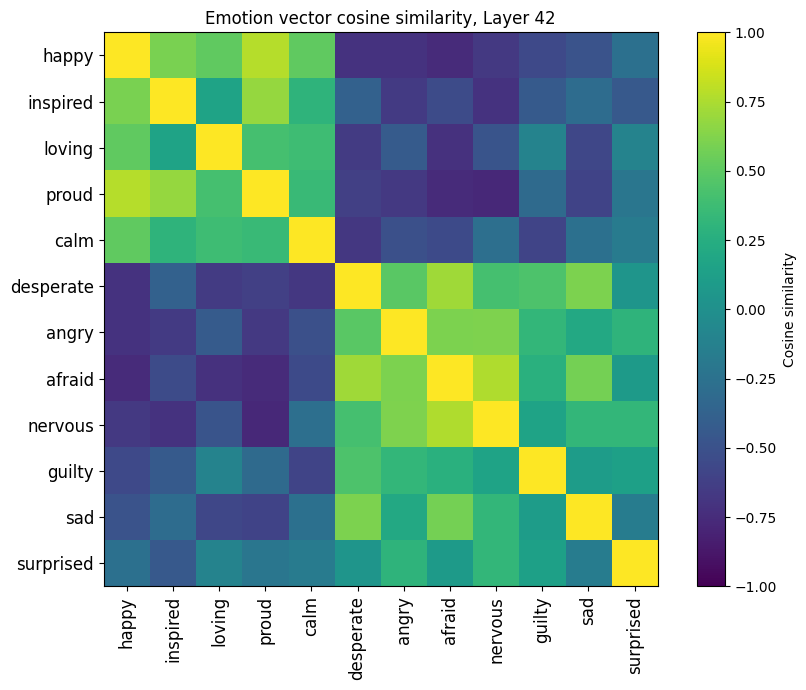

In [7]:
emotions = list(cleaned_emotions_by_layer[42].keys())
V = np.stack([cleaned_emotions_by_layer[42][emotion] for emotion in emotions])

cos_sim = cosine_similarity(V)

plt.figure(figsize=(9, 7))
plt.imshow(cos_sim, vmin=-1, vmax=1)
plt.colorbar(label="Cosine similarity")
plt.xticks(range(len(emotions)), emotions, rotation=90, fontsize=12)
plt.yticks(range(len(emotions)), emotions, fontsize=12)
plt.title(f"Emotion vector cosine similarity, Layer 42", fontsize=12)
plt.tight_layout()
plt.show()

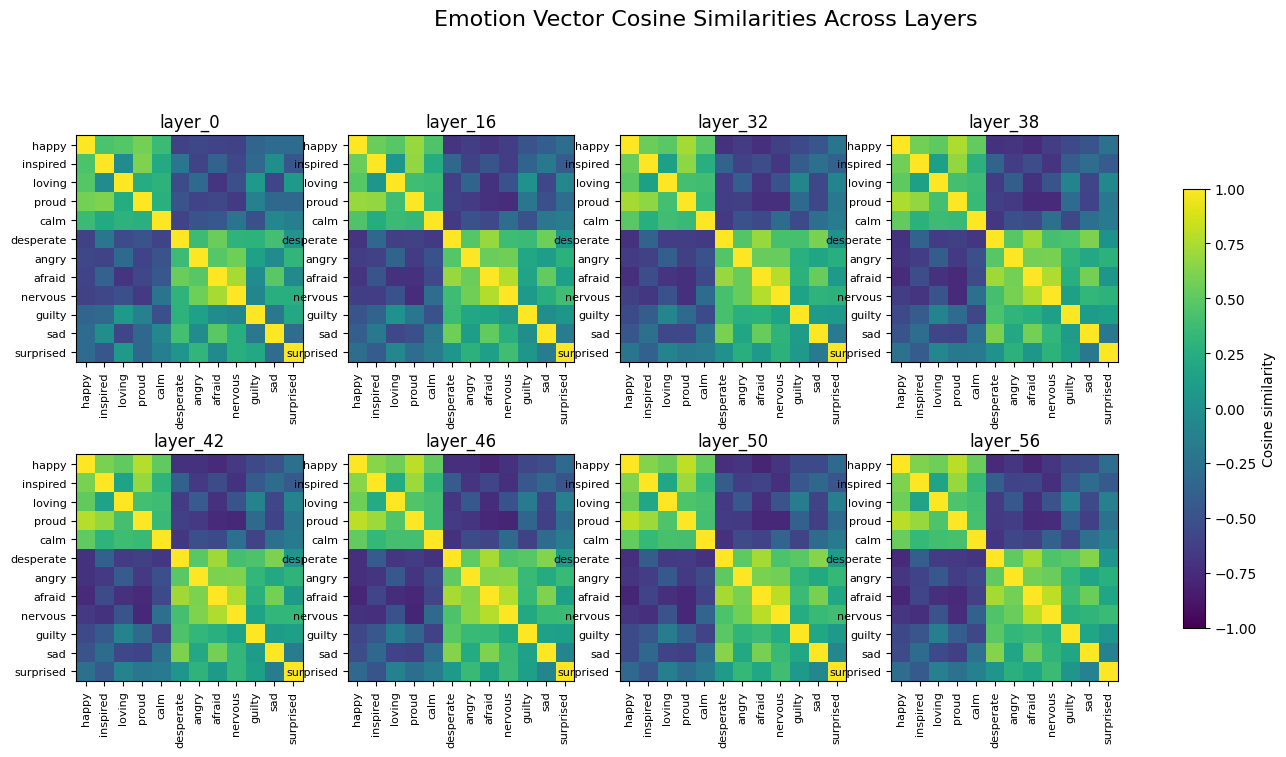

In [10]:
emotions = cfg.EMOTIONS

with h5py.File(data_dir, "r") as f_in:
    layers_to_plot = sorted(
        f_in["neutral"].keys(),
        key=lambda name: int(name.replace("layer_", "")),
    )

n_layers = len(layers_to_plot)
n_cols = min(4, n_layers)
n_rows = int(np.ceil(n_layers / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.8 * n_rows), squeeze=False)

last_im = None
for ax, layer_name in zip(axes.flat, layers_to_plot):
    layer_idx = int(layer_name.replace("layer_", ""))
    V = np.stack([cleaned_emotions_by_layer[layer_idx][e] for e in emotions])
    cos_sim = cosine_similarity(V)
    last_im = ax.imshow(cos_sim, vmin=-1, vmax=1)
    ax.set_title(layer_name, fontsize=12)
    ax.set_xticks(range(len(emotions)))
    ax.set_yticks(range(len(emotions)))
    ax.set_xticklabels(emotions, rotation=90, fontsize=8)
    ax.set_yticklabels(emotions, fontsize=8)

for ax in axes.flat[n_layers:]:
    ax.axis("off")

fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.75, label="Cosine similarity")
fig.suptitle("Emotion Vector Cosine Similarities Across Layers", fontsize=16, y=1.02)
plt.show()

In [13]:
print(layers_to_plot)

['layer_0', 'layer_16', 'layer_32', 'layer_38', 'layer_42', 'layer_46', 'layer_50', 'layer_56']


Explained variance ratio: [0.5468527  0.13072418]
Total variance explained: 0.6775769


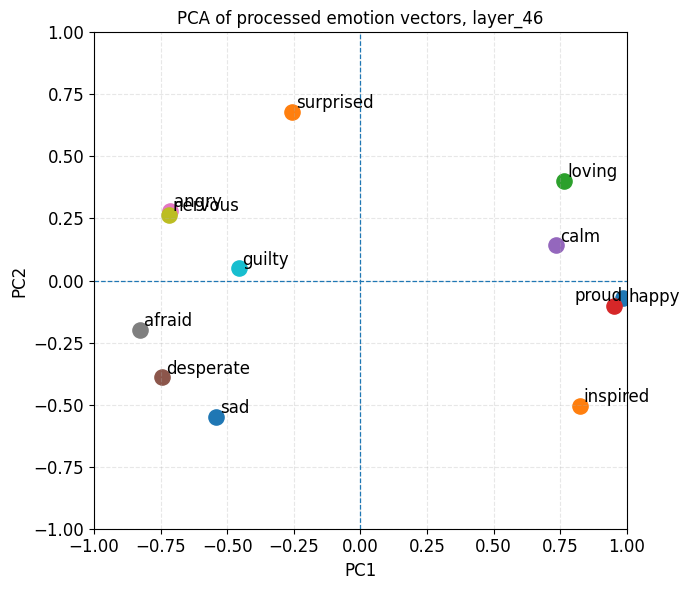

In [20]:
inspect_layer = layers_to_plot[5]
cleaned_emotions = cleaned_emotions_by_layer[int(inspect_layer.replace("layer_", ""))]

# Stack emotion vectors
emotions = list(cleaned_emotions.keys())
V = np.stack([cleaned_emotions[e] for e in emotions])

# PCA to 2D
pca = PCA(n_components=2)
V_2d = pca.fit_transform(V)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

# Plot
plt.figure(figsize=(7, 6))

for i, emotion in enumerate(emotions):
    x, y = V_2d[i]
    plt.scatter(x, y, s=120)
    if emotion not in ["happy", "proud"]:
        plt.text(x + 0.015, y + 0.015, emotion, fontsize=12)
    elif emotion == "proud":
        plt.text(x - 0.15, y + 0.02, emotion, fontsize=12)
    else:
        plt.text(x + 0.02, y - 0.018, emotion, rotation=0, fontsize=12)


plt.axhline(0, linewidth=0.9, linestyle="--")
plt.axvline(0, linewidth=0.9, linestyle="--")

plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.title(f"PCA of processed emotion vectors, {inspect_layer}", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### And it works!!!!!